# 04. CNN на PyTorch: классификация Fashion-MNIST

Обучение и оценка `FashionCNN` (см. `src/part2_pytorch/`) на Fashion-MNIST.
Ноутбук читает результаты, сохранённые `train.py` (`history.json`) и `evaluate.py`
(`evaluation_results.json`) — сами обучение и оценку запускать здесь не нужно, если
вы уже прогнали оба скрипта из терминала.


In [3]:
import sys
sys.path.append('../src/part2_pytorch')

import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms

from train import CLASS_NAMES


## Кривые обучения: loss и accuracy по эпохам


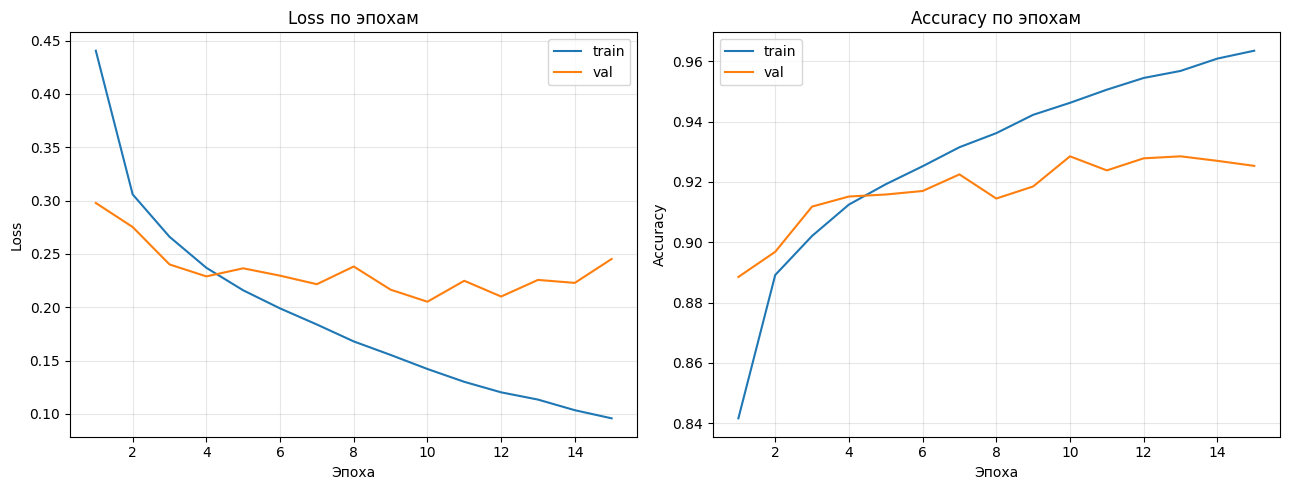

Лучшая val accuracy: 0.9285


In [5]:
with open('../src/part2_pytorch/history.json') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs, history['train_loss'], label='train')
axes[0].plot(epochs, history['val_loss'], label='val')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss по эпохам')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_acc'], label='train')
axes[1].plot(epochs, history['val_acc'], label='val')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy по эпохам')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/cnn_loss_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Лучшая val accuracy: {max(history['val_acc']):.4f}")


## Confusion matrix на test set


In [6]:
with open('../src/part2_pytorch/evaluation_results.json') as f:
    eval_results = json.load(f)

test_accuracy = eval_results['test_accuracy']
cm = np.array(eval_results['confusion_matrix'])

print(f"Test accuracy: {test_accuracy:.4f}")


Test accuracy: 0.9199


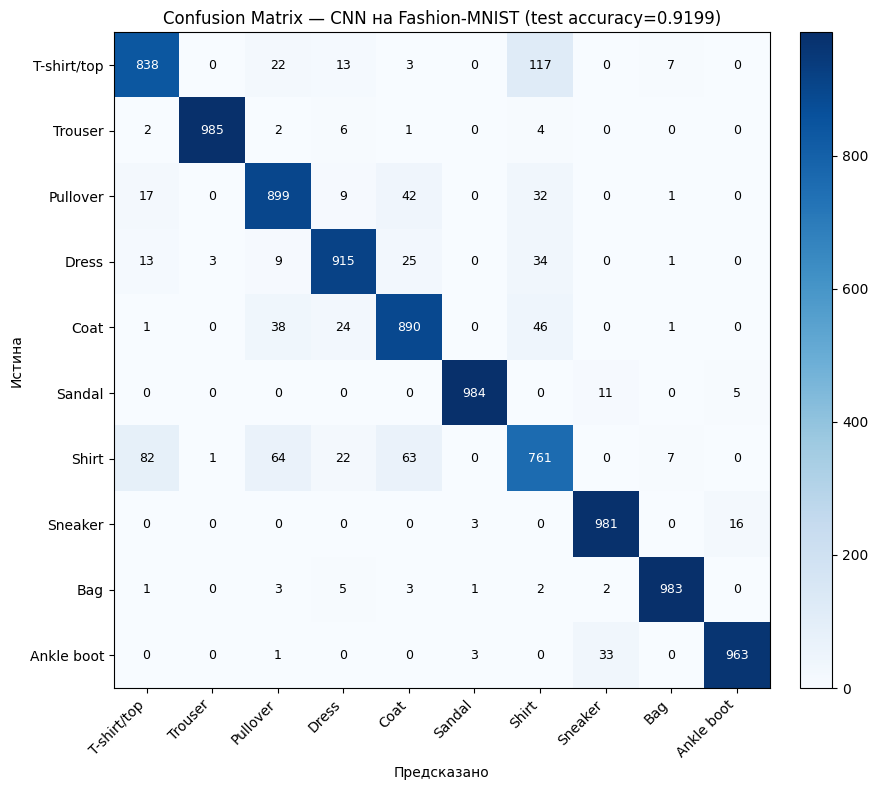

In [7]:
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap='Blues')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=9)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истина')
ax.set_title(f'Confusion Matrix — CNN на Fashion-MNIST (test accuracy={test_accuracy:.4f})')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('../results/cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## Какие классы модель путает сильнее всего


In [10]:
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)

flat_idx = np.argsort(cm_off_diag.ravel())[::-1][:5]
print("Топ-5 самых частых ошибок (истина -> предсказано: количество):")
for idx in flat_idx:
    i, j = np.unravel_index(idx, cm_off_diag.shape)
    count = cm_off_diag[i, j]
    if count > 0:
        print(f"  {CLASS_NAMES[i]:12s} -> {CLASS_NAMES[j]:12s}: {count}")


Топ-5 самых частых ошибок (истина -> предсказано: количество):
  T-shirt/top  -> Shirt       : 117
  Shirt        -> T-shirt/top : 82
  Shirt        -> Pullover    : 64
  Shirt        -> Coat        : 63
  Coat         -> Shirt       : 46


## Примеры ошибок модели

Загружаем test set заново, чтобы достать реальные изображения по индексам,
сохранённым в `evaluation_results.json`.


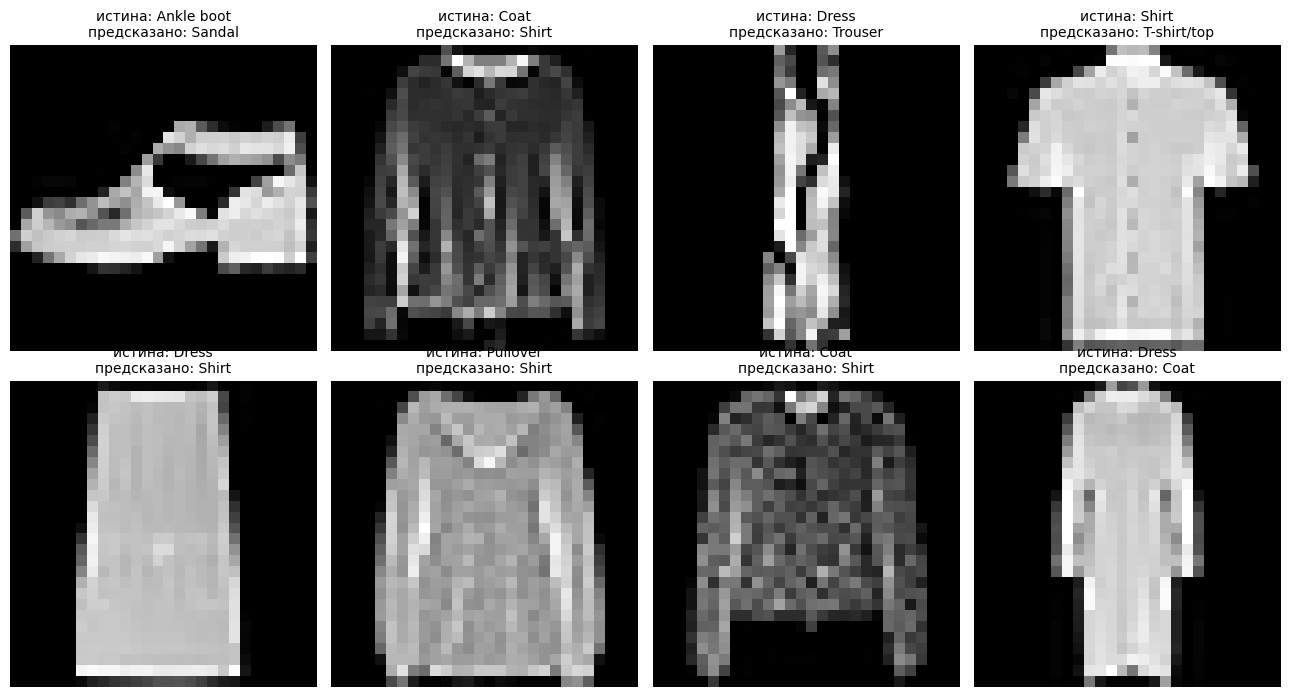

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])
test_set = datasets.FashionMNIST(root='../data', train=False, download=True, transform=transform)

wrong_idx = eval_results['misclassified_indices']
true_labels = eval_results['misclassified_true_labels']
pred_labels = eval_results['misclassified_pred_labels']

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, idx, true_l, pred_l in zip(axes.flat, wrong_idx, true_labels, pred_labels):
    image, _ = test_set[idx]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'истина: {CLASS_NAMES[true_l]}\nпредсказано: {CLASS_NAMES[pred_l]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../results/cnn_misclassified_examples.png', dpi=150, bbox_inches='tight')
plt.show()


## Выводы

- Итоговая **test accuracy: 91.99%**, что заметно выше базового уровня для Fashion-MNIST
  простой CNN без агрессивного тюнинга.
- Модель почти идеально различает структурно непохожие классы: `Trouser` (99.6% precision),
  `Sandal` (99.3%), `Bag` (98.3%) — эти вещи визуально сильно отличаются от остальных.
- Главная проблема — класс `Shirt` (76.4% precision, 76.1% recall): его чаще всего путают с
  `T-shirt/top` и `Coat`. Это ожидаемо — рубашка, футболка и пальто на маленьких 28x28
  grayscale-изображениях действительно похожи по силуэту, разница в основном в деталях
  (рукава, воротник), которые на таком разрешении плохо различимы.
- Confusion matrix подтверждает: путаница сконцентрирована в кластере
  `T-shirt/top - Pullover - Coat - Shirt` — все это виды верхней одежды с похожим силуэтом.
  Обувь и сумки (Sandal, Sneaker, Ankle boot, Bag, Trouser) распознаются почти без ошибок.
